# Dexed dataset audit

Explore the Dexed dataset: link audio to preset parameters, extract descriptors, and build coverage maps of the behaviour space -- ending with the exact 38-feature space (6 ACTM + 32 TT) used by SpinVAE2's timbre loss.

## 1. Setup and paths

In [1]:
import os, sys, glob, re
os.environ['LD_LIBRARY_PATH'] = '/data/anasynth_nonbp/manaconda3/lib:' + os.environ.get('LD_LIBRARY_PATH','')

PROJECT_ROOT = os.path.expanduser('~/projects/spinvae2')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display

DATASET_ROOT = '/data2/anasynth_nonbp/longeot/spinvae2_datasets/Dexed'
AUDIO_DIR = os.path.join(DATASET_ROOT, 'Audio')
PITCH, VEL = 56, 75

print('Audio dir exists:', os.path.isdir(AUDIO_DIR))
print('Nb wav files   :', len(glob.glob(os.path.join(AUDIO_DIR, '*.wav'))))

Audio dir exists: True
Nb wav files   : 120580


In [2]:
from synth.dexed import PresetDfDatabase
from synth.dexed import Dexed

db = PresetDfDatabase()
print('Nb presets in DB:', db.nb_presets)

def wav_path(uid, variation=0, pitch=PITCH, vel=VEL):
    stem = f"{uid:06d}_pitch{pitch:03d}vel{vel:03d}_var{variation:03d}.wav"
    return os.path.join(AUDIO_DIR, stem)

def uid_from_filename(fname):
    m = re.match(r"(\d{6})_", os.path.basename(fname))
    return int(m.group(1)) if m else None

all_uids = list(db.all_preset_UIDs)
print('Example UID:', all_uids[0], '->', wav_path(all_uids[0]))

Nb presets in DB: 30145
Example UID: 0 -> /data2/anasynth_nonbp/longeot/spinvae2_datasets/Dexed/Audio/000000_pitch056vel075_var000.wav


## 2. Explore a single preset

UID 0  |  BRITE RDS  (INCONI19)  |  var0


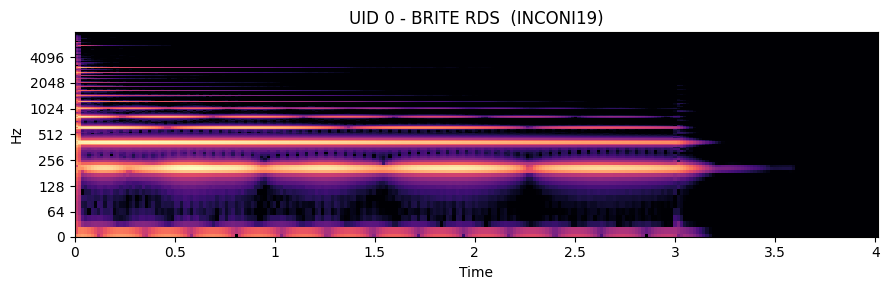

In [3]:
def explore_preset(uid, variation=0):
    name = db.get_preset_name(uid, long_name=True)
    path = wav_path(uid, variation)
    audio, sr = sf.read(path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    print(f"UID {uid}  |  {name}  |  var{variation}")
    S = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=1024, hop_length=256)), ref=np.max)
    fig, ax = plt.subplots(figsize=(9,3))
    librosa.display.specshow(S, sr=sr, hop_length=256, x_axis='time', y_axis='log', ax=ax)
    ax.set_title(f"UID {uid} - {name}")
    plt.tight_layout(); plt.show()
    display(Audio(audio, rate=sr))

explore_preset(all_uids[0])

## 3. Lightweight librosa descriptors (first pass)

Generic audio features, computed quickly on a sample -- a first, rough look before using the perceptually-grounded 38-feature space (section 5).

In [4]:
def compute_librosa_descriptors(audio, sr):
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if np.abs(audio).max() < 1e-6:
        return None
    feats = {}
    S = np.abs(librosa.stft(audio, n_fft=1024, hop_length=256))
    feats['centroid']  = float(np.mean(librosa.feature.spectral_centroid(S=S, sr=sr)))
    feats['bandwidth'] = float(np.mean(librosa.feature.spectral_bandwidth(S=S, sr=sr)))
    feats['rolloff']   = float(np.mean(librosa.feature.spectral_rolloff(S=S, sr=sr)))
    feats['flatness']  = float(np.mean(librosa.feature.spectral_flatness(S=S)))
    feats['rms']       = float(np.mean(librosa.feature.rms(S=S)))
    return feats

## 4. Perceptual descriptors: TimbreToolbox + AudioCommons

SpinVAE2's timbre loss uses **TimbreToolbox (TT)** and **AudioCommons Timbral Models (ACTM)** features, from
which an unsupervised correlation-based selection keeps 32 TT + 6 ACTM = **38 features** (`a in R^38` in the paper).

TT requires MATLAB (available on `bonsho`, not on `gottan`). The dataset's timbre features are computed via
`ds.compute_and_store_timbre_features()`, which writes `raw_timbre_features.df.pickle` -- loaded below.

In [5]:
import pathlib
from utils.timbrefeatures import TimbreFeatures, parse_timbre_features_arguments

raw_pickle = pathlib.Path(DATASET_ROOT) / 'raw_timbre_features.df.pickle'
raw_df = pd.read_pickle(raw_pickle)
print('Raw shape:', raw_df.shape)
print('Presets couverts:', raw_df['preset_UID'].nunique())

Raw shape: (241160, 97)
Presets couverts: 30145


In [6]:
# Apply the exact SpinVAE2 paper selection: log-scale + z-score normalisation (TimbreFeatures),
# then keep only the 38 features surviving the >0.9 correlation filter.
tf = TimbreFeatures(raw_pickle)
selected_38 = parse_timbre_features_arguments(['ac_*', 'tt_*', '__no_high_corr__'])
ac_38 = [f for f in selected_38 if f.startswith('ac_')]
tt_38 = [f for f in selected_38 if f.startswith('tt_')]
print(f'ACTM: {len(ac_38)} (papier: 6)')
print(f'TT: {len(tt_38)} (papier: 32)')

behaviour_df = tf.postproc_df[['preset_UID', 'variation'] + selected_38].copy()
behaviour_df = behaviour_df[behaviour_df['variation'] == 0].set_index('preset_UID')
print('Behaviour space (var0 only):', behaviour_df.shape)

ACTM: 6 (papier: 6)
TT: 32 (papier: 32)
Behaviour space (var0 only): (30145, 39)


## 5. Coverage map in the canonical 38-feature behaviour space

This is the actual behaviour space $Z$ used by SpinVAE2's timbre loss -- the map future IMGEP exploration will
be compared against.

Explained variance (2 PCs): 0.46047395754701315


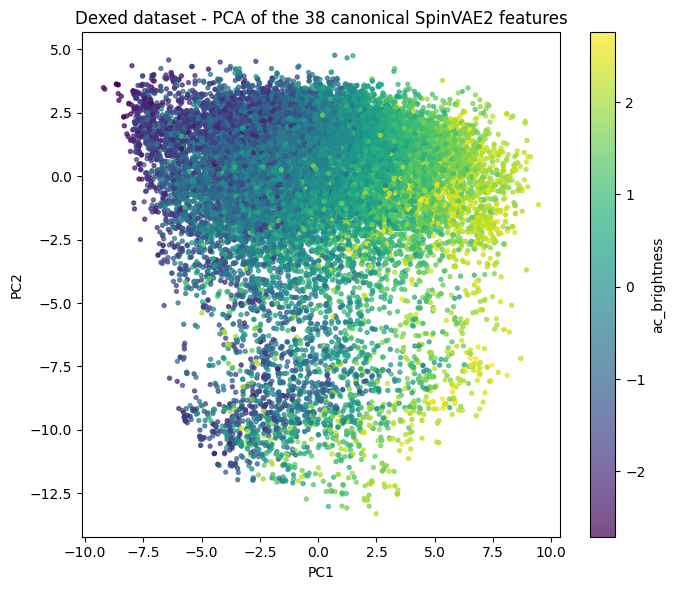

In [7]:
from sklearn.decomposition import PCA

X38 = np.nan_to_num(behaviour_df[selected_38].values)
pca38 = PCA(n_components=2)
X38p = pca38.fit_transform(X38)
print('Explained variance (2 PCs):', pca38.explained_variance_ratio_[:2].sum())

color_col = 'ac_brightness'
fig, ax = plt.subplots(figsize=(7,6))
sc = ax.scatter(X38p[:,0], X38p[:,1], c=behaviour_df[color_col], s=8, cmap='viridis', alpha=0.7)
plt.colorbar(sc, label=color_col)
ax.set_title('Dexed dataset - PCA of the 38 canonical SpinVAE2 features')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.show()

/data/anasynth_nonbp/longeot/envs/spinvae_2_18_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


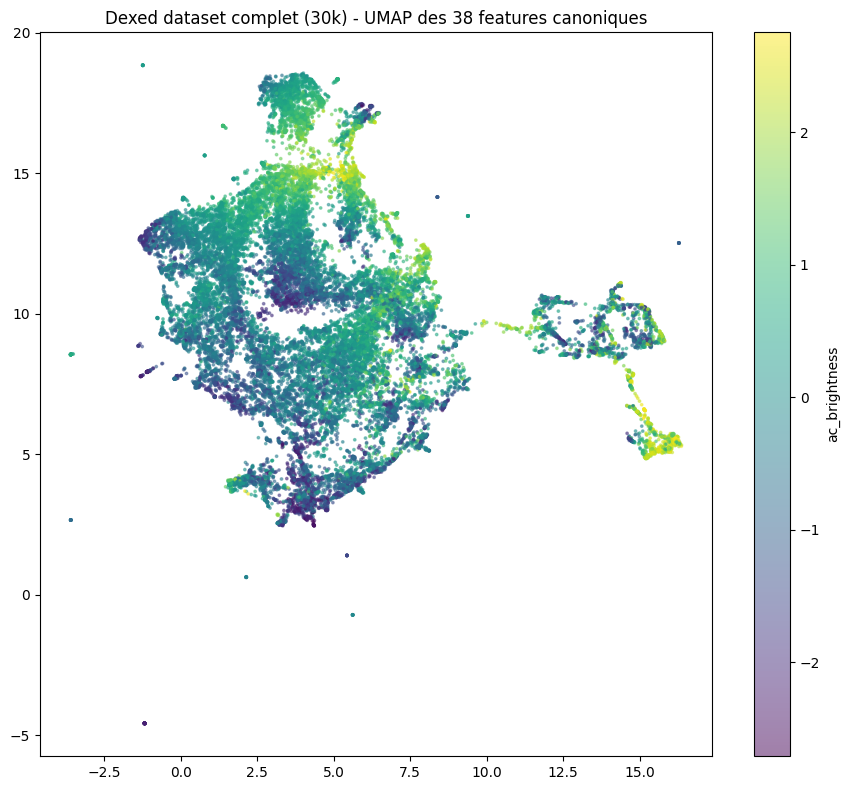

In [8]:
try:
    import sys
    sys.modules['umap.parametric_umap'] = None  # empêche l'import qui plante
    import umap
    reducer38 = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
    reducer38 = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
    X38u = reducer38.fit_transform(X38)

    fig, ax = plt.subplots(figsize=(9,8))
    sc = ax.scatter(X38u[:,0], X38u[:,1], c=behaviour_df['ac_brightness'], s=3, cmap='viridis', alpha=0.5)
    plt.colorbar(sc, label='ac_brightness')
    ax.set_title('Dexed dataset complet (30k) - UMAP des 38 features canoniques')
    plt.tight_layout(); plt.show()
    behaviour_df['umap_x'], behaviour_df['umap_y'] = X38u[:,0], X38u[:,1]
except ImportError:
    print('umap-learn not installed. Run: pip install umap-learn')
behaviour_df['pca_x'], behaviour_df['pca_y'] = X38p[:,0], X38p[:,1]

### 5bis. Same map, coloured by a spectral (TT) feature

`ac_brightness` is a semantic/perceptual descriptor. Colouring by a raw spectral TT feature
(`tt_SpecCent_IQR`, the interquartile range of spectral centroid over time -- a proxy for
how much the timbre's brightness varies within a single note) checks whether the map's
structure is specific to one descriptor or reflects a more general organisation.

/data/anasynth_nonbp/longeot/envs/spinvae_2_18_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


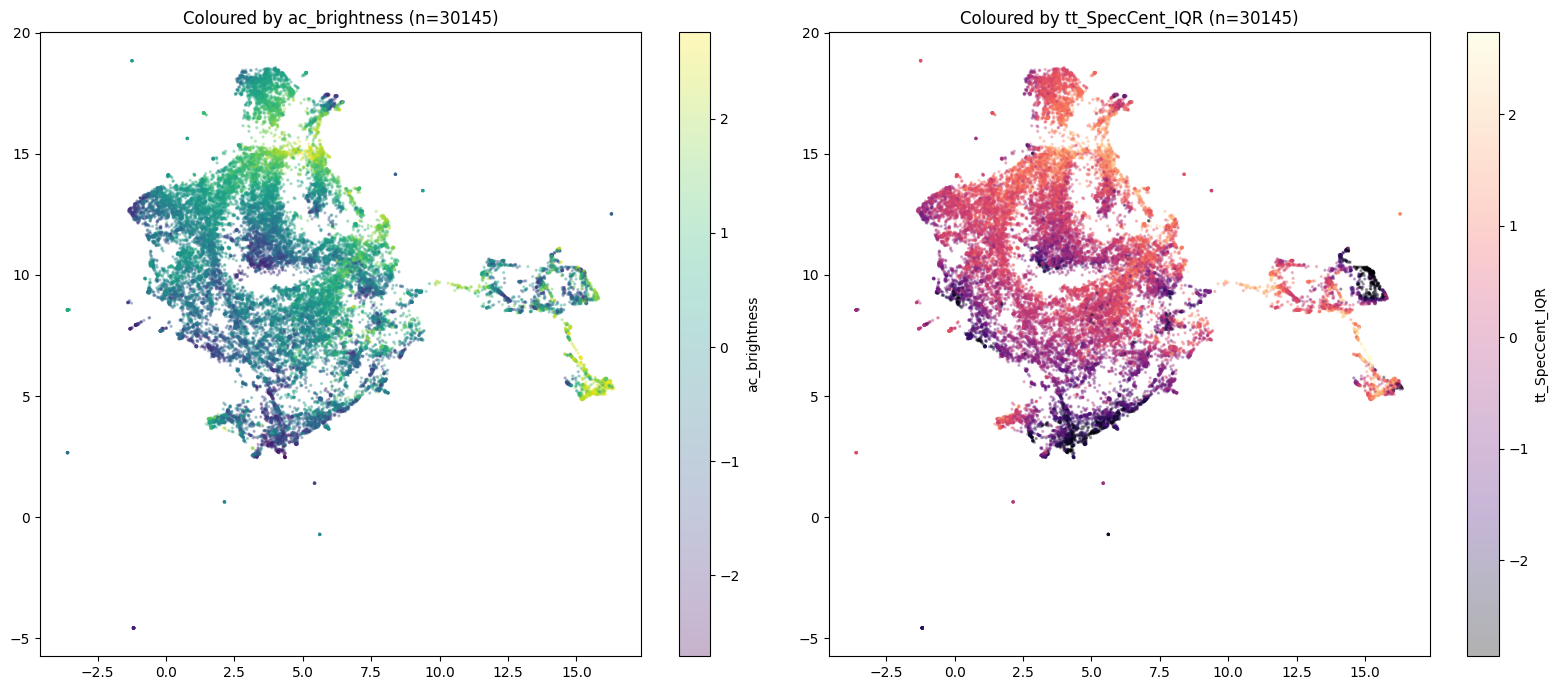

In [10]:
reducer38b = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
X38u_b = reducer38b.fit_transform(X38)  # same embedding params, kept separate for clarity

fig, axes = plt.subplots(1, 2, figsize=(16,7))
sc0 = axes[0].scatter(X38u_b[:,0], X38u_b[:,1], c=behaviour_df['ac_brightness'], s=2, cmap='viridis', alpha=0.3)
plt.colorbar(sc0, ax=axes[0], label='ac_brightness')
axes[0].set_title(f'Coloured by ac_brightness (n={len(X38u_b)})')

sc1 = axes[1].scatter(X38u_b[:,0], X38u_b[:,1], c=behaviour_df['tt_SpecCent_IQR'], s=2, cmap='magma', alpha=0.3)
plt.colorbar(sc1, ax=axes[1], label='tt_SpecCent_IQR')
axes[1].set_title(f'Coloured by tt_SpecCent_IQR (n={len(X38u_b)})')
plt.tight_layout(); plt.show()

### 5ter. Quantifying coverage

Two simple, standard Quality-Diversity coverage metrics, computed on the UMAP embedding:
- **Grid occupancy**: divide the 2D map into an N x N grid, count occupied cells / total cells.
- **Mean nearest-neighbour distance**: average distance from each point to its closest neighbour
  -- higher values indicate sparser, more uneven coverage.

These give a numeric baseline to compare against once IMGEP-guided exploration is available.

In [9]:
from scipy.spatial import cKDTree

def grid_occupancy(points, n_bins=20):
    x, y = points[:,0], points[:,1]
    x_edges = np.linspace(x.min(), x.max(), n_bins+1)
    y_edges = np.linspace(y.min(), y.max(), n_bins+1)
    H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    occupied = (H > 0).sum()
    total = n_bins * n_bins
    return occupied / total, occupied, total

def mean_nn_distance(points):
    tree = cKDTree(points)
    dists, _ = tree.query(points, k=2)  # k=1 is itself (dist 0), k=2 is the true nearest neighbour
    return float(np.mean(dists[:,1]))

occ_ratio, occ_cells, total_cells = grid_occupancy(X38u, n_bins=50)
nn_dist = mean_nn_distance(X38u)
print(f"Grid occupancy (50x50): {occ_cells}/{total_cells} cells = {100*occ_ratio:.1f}%")
print(f"Mean nearest-neighbour distance: {nn_dist:.4f}")
print(f"(sur {len(X38u)} presets)")

Grid occupancy (50x50): 671/2500 cells = 26.8%
Mean nearest-neighbour distance: 0.0228
(sur 30145 presets)


## 5quater. Coverage map in the raw parameter space (Θ)

Same PCA/UMAP/coverage analysis, but performed directly on the 155 raw Dexed parameters
instead of the 38-feature behaviour space. This checks whether human-made presets cover
the parameter space Θ as unevenly as they cover the perceptual behaviour space Z, and
whether the two spaces show a similar or markedly different structure -- which would
be informative about the non-linearity of the Θ→Z mapping that SpinVAE2 itself is
built to learn.

In [11]:
# Récupérer les paramètres bruts pour tous les presets (variation 0 = presets originaux)
from synth.dexed import PresetDfDatabase
db = PresetDfDatabase()

all_uids_ordered = list(behaviour_df.index)  # même ordre que le comportement, pour comparer
params_matrix = np.array([db.get_preset_params_values(uid) for uid in all_uids_ordered])
print("Shape params bruts:", params_matrix.shape)  # attendu: (30145, 155)

Shape params bruts: (30145, 155)


Explained variance Theta (2 PCs): 0.17467707


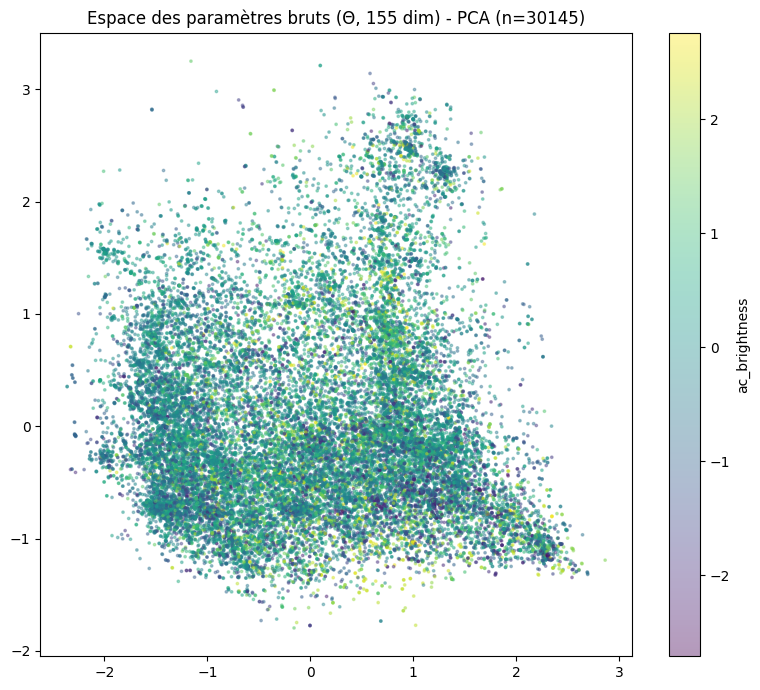

In [12]:
pca_theta = PCA(n_components=2)
Xtheta_p = pca_theta.fit_transform(params_matrix)
print('Explained variance Theta (2 PCs):', pca_theta.explained_variance_ratio_[:2].sum())

fig, ax = plt.subplots(figsize=(8,7))
sc = ax.scatter(Xtheta_p[:,0], Xtheta_p[:,1], c=behaviour_df['ac_brightness'], s=3, cmap='viridis', alpha=0.4)
plt.colorbar(sc, label='ac_brightness')
ax.set_title(f'Espace des paramètres bruts (Θ, 155 dim) - PCA (n={len(params_matrix)})')
plt.tight_layout(); plt.show()

/data/anasynth_nonbp/longeot/envs/spinvae_2_18_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


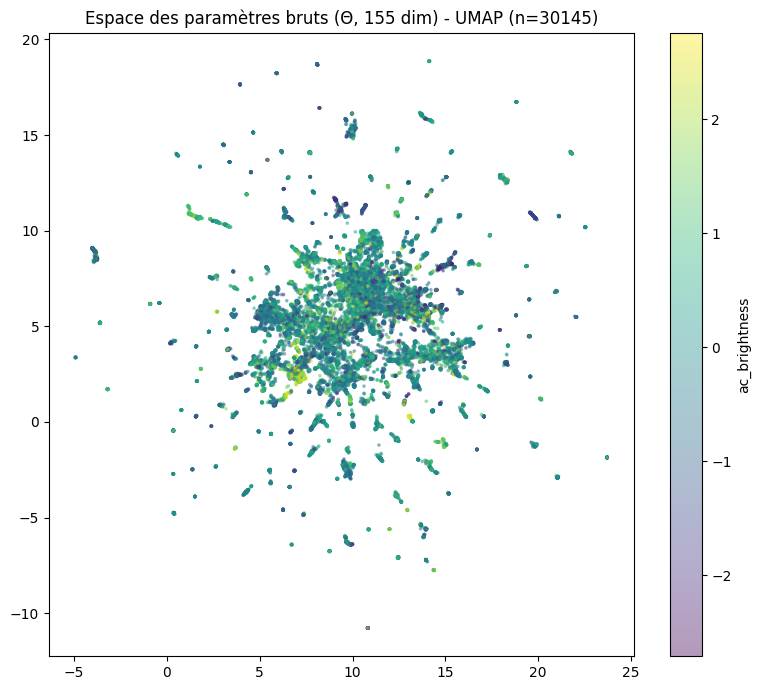

In [13]:
reducer_theta = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
Xtheta_u = reducer_theta.fit_transform(params_matrix)

fig, ax = plt.subplots(figsize=(8,7))
sc = ax.scatter(Xtheta_u[:,0], Xtheta_u[:,1], c=behaviour_df['ac_brightness'], s=3, cmap='viridis', alpha=0.4)
plt.colorbar(sc, label='ac_brightness')
ax.set_title(f'Espace des paramètres bruts (Θ, 155 dim) - UMAP (n={len(params_matrix)})')
plt.tight_layout(); plt.show()

In [14]:
occ_ratio_theta, occ_cells_theta, total_cells_theta = grid_occupancy(Xtheta_u, n_bins=50)
nn_dist_theta = mean_nn_distance(Xtheta_u)
print(f"Grid occupancy Theta (50x50): {occ_cells_theta}/{total_cells_theta} = {100*occ_ratio_theta:.1f}%")
print(f"Mean NN distance Theta: {nn_dist_theta:.4f}")

Grid occupancy Theta (50x50): 513/2500 = 20.5%
Mean NN distance Theta: 0.0141


### Summary of results so far

- The canonical 38-feature behaviour space (6 ACTM + 32 TT, exactly matching the SpinVAE2 paper's
  selection) was successfully reproduced from the regenerated Dexed dataset.
- PCA on this space explains ~44% of variance on 2 components -- the space is genuinely
  multi-dimensional, no single pair of axes summarises it well.
- The UMAP projection shows a broadly connected structure, but with visibly denser and sparser
  sub-regions, and at least one small, distinctly separated cluster of bright/high-`ac_brightness`
  presets, isolated from the main body of points.
- Colouring by a purely spectral TT feature (`tt_SpecCent_IQR`) shows a similar (though not
  identical) organisation to the semantic ACTM feature, suggesting the map's structure is not an
  artefact of one specific descriptor.
- Grid occupancy and nearest-neighbour distance give a first quantitative coverage baseline,
  computed on 500 presets so far -- to be recomputed on the full 30k-preset dataset once the
  ongoing TT+ACTM computation on `bonsho` finishes.

## 6. Select and export sounds to download

Pick UIDs of interest (e.g. sparse regions of the canonical map) and copy their wav files, then from your
local machine: `scp 'bonsho:~/to_download/*.wav' ~/dexed_listen/`

In [ ]:
import shutil
DL_DIR = os.path.expanduser('~/to_download')
os.makedirs(DL_DIR, exist_ok=True)

def export_for_download(uids, variation=0):
    copied = []
    for uid in uids:
        src = wav_path(uid, variation)
        if os.path.exists(src):²
            name = db.get_preset_name(uid).replace('/', '_').replace(' ', '_')
            dst = os.path.join(DL_DIR, f"{uid:06d}_{name}.wav")
            shutil.copy(src, dst)
            copied.append(dst)
    print(f"Copied {len(copied)} files to {DL_DIR}")
    return copied

example_uids = list(behaviour_df.sample(min(10, len(behaviour_df)), random_state=1).index)
export_for_download(example_uids)

Copied 10 files to /u/anasynth/longeot/to_download


['/u/anasynth/longeot/to_download/000310_Bell<Wahh>.wav',
 '/u/anasynth/longeot/to_download/000346_DINGL_19.7.wav',
 '/u/anasynth/longeot/to_download/000048_CHURCHORG3.wav',
 '/u/anasynth/longeot/to_download/000069_CHORUS_CLV.wav',
 '/u/anasynth/longeot/to_download/000519___DX9._9__.wav',
 '/u/anasynth/longeot/to_download/000526_DX9.BR-CHM.wav',
 '/u/anasynth/longeot/to_download/000316_BELLAPHON_.wav',
 '/u/anasynth/longeot/to_download/000032_SYNORGAN_K.wav',
 '/u/anasynth/longeot/to_download/000253_NEW_RHODES.wav',
 '/u/anasynth/longeot/to_download/000093__CLANG_MW_.wav']

### Next steps
- Once the full-dataset (30k presets) TT+ACTM computation finishes on `bonsho`, reload `raw_timbre_features.df.pickle`
  here and re-run sections 4-5 on the complete behaviour space.
- Quantify coverage (convex hull area, grid-cell occupancy, nearest-neighbour distances) as the baseline
  to compare against IMGEP-guided exploration.
- Compare this canonical 38-feature map against the earlier librosa-only map (section 3) to check whether
  the same dense/sparse regions appear in both.